In [1]:
# Importamos las librerías necesarias para comunicación con la web y manejo de archivos
import urllib.request
import os
import time

# Definimos la fuente: La API de Datos Abiertos del Gobierno Colombiano.
# Seleccionamos solo 3 columnas para optimizar el peso del archivo final.
url_fuente = "https://www.datos.gov.co/resource/gt2j-8ykr.csv?$limit=10000000&$select=departamento_nom,estado,edad"

# Nombre del archivo donde guardaremos los datos localmente
archivo_datos = "dataset_covid_completo.csv"

print("Descargando el archivo...")

# Marcamos el tiempo de inicio para medir el rendimiento de la descarga
tiempo_inicio = time.time()

try:
    # urlretrieve descarga el archivo directamente al disco duro
    urllib.request.urlretrieve(url_fuente, archivo_datos)
    tiempo_fin = time.time()
    
    # Calculamos el peso del archivo en Megabytes
    peso_archivo = os.path.getsize(archivo_datos) / (1024 * 1024)
    
    print(f"\nDescarga exitosa")
    
except Exception as e:
    # Si se corta la coneccion o ocurre algun error al momento de la descarga se mostrara:
    print(f"\nError durante la descarga: {e}")

Descargando el archivo...

Descarga exitosa


In [2]:
# Importamos las herramientas de Spark y de análisis local (Pandas)
from pyspark.sql import SparkSession
import pandas as pd

def ejecutar_procesamiento():
    try:
        # Configuramos la sesión de Spark dándole un nombre y asignando memoria
        spark = SparkSession.builder \
            .appName("Analisis_WebScraping") \
            .config("spark.driver.memory", "4g") \
            .getOrCreate()
        
        # Leemos el archivo CSV usando Spark
        df_spark = spark.read.csv(archivo_datos, header=True, inferSchema=True)
        
        # Mostramos una pequeña muestra para demostrar la lectura exitosa
        df_spark.show(10)
        
        # Contamos cuántos millones de registros hay realmente
        conteo_total = df_spark.count()
        
        # Realizamos las transformaciones de Big Data
        from pyspark.sql.functions import col, upper
        resultado_spark = df_spark.withColumn("dep", upper(col("departamento_nom"))) \
                                  .groupBy("dep").count() \
                                  .orderBy(col("count").desc())
        
        return resultado_spark.limit(10).toPandas(), "Apache Spark Cluster"

    except Exception as e:
        # Leemos el archivo usando la memoria
        df_pd = pd.read_csv(archivo_datos)
        
        # Mostramos una pequeña muestra para demostrar la lectura exitosa en Pandas
        print(df_pd.head(10))
        
        # Aplicamos la lógica de limpieza y agrupación
        df_pd['dep'] = df_pd['departamento_nom'].astype(str).str.upper()
        res_pd = df_pd['dep'].value_counts().reset_index().head(10)
        res_pd.columns = ['dep', 'count']
        
        print("Análisis completo")
        return res_pd, "Pandas"

# Ejecutamos la función y guardamos el resultado
df_final, motor_utilizado = ejecutar_procesamiento()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 21:37:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


  departamento_nom     estado  edad
0            VALLE       Leve    67
1            VALLE       Leve    66
2            VALLE       Leve    68
3            VALLE  Fallecido    74
4            VALLE       Leve    65
5            VALLE       Leve    66
6            VALLE       Leve    74
7            VALLE  Fallecido    66
8            VALLE       Leve    64
9            VALLE       Leve    65
Análisis completo


/tmp/ipykernel_2406214/3681843484.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafica = sns.barplot(data=df_final, x='dep', y='count', palette="viridis")


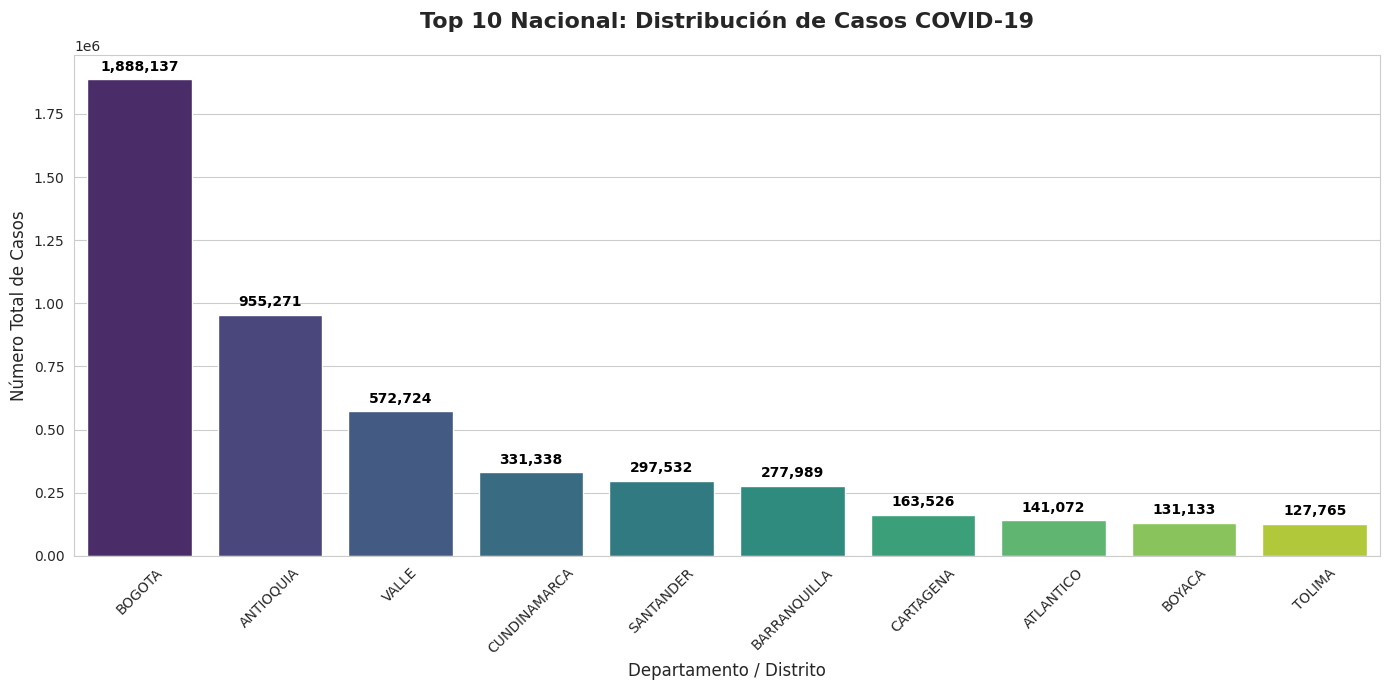

In [4]:
# Importamos librerías gráficas de alto nivel
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual del gráfico
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Creamos el gráfico de barras usando Seaborn
# Usamos una paleta de colores llamativa ("viridis")
grafica = sns.barplot(data=df_final, x='dep', y='count', palette="viridis")

# Añadimos los títulos y etiquetas profesionales
plt.title(f'Top 10 Nacional: Distribución de Casos COVID-19', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Número Total de Casos", fontsize=12)
plt.xlabel("Departamento / Distrito", fontsize=12)
plt.xticks(rotation=45)

# Bucle para poner los números exactos encima de cada barra
for p in grafica.patches:
    grafica.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, 
                    color='black',
                    fontweight='bold')

# Ajustamos el diseño para que no se corten las etiquetas
plt.tight_layout()

# Mostramos el gráfico final
plt.show()